<a href="https://colab.research.google.com/github/JoaoGustavoNobreGois/Computacao-Distribuida/blob/master/Exercicios_1_1_e_1_2_Computacao_Distribuida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computação Distribuída — Exercícios 1.1 e 1.2
## Disponibilidade de serviços replicados

Parâmetros usados:

- \(n\): número total de servidores, com \(n>0\);
- \(k\): quantidade mínima de servidores disponíveis para o serviço funcionar, com \(0<k\le n\);
- \(p\): probabilidade de cada servidor estar disponível, com \(0\le p\le1\).

Assumimos que os servidores têm a mesma probabilidade \(p\) e que suas disponibilidades são independentes.


# Exercício 1.1 — Dedução da fórmula matemática

Seja \(X\) o número de servidores disponíveis em um determinado instante.

Como cada servidor pode estar disponível ou indisponível, e cada um possui probabilidade \(p\) de estar disponível:

\[
X \sim Binomial(n,p)
\]

A probabilidade de exatamente \(i\) servidores estarem disponíveis é:

\[
P(X=i)=\binom{n}{i}p^i(1-p)^{n-i}
\]

O serviço permanece operacional quando pelo menos \(k\) dos \(n\) servidores estão disponíveis:

\[
X \ge k
\]

Portanto, a disponibilidade do serviço é:

\[
\boxed{
A(n,k,p)=
\sum_{i=k}^{n}
\binom{n}{i}
p^i(1-p)^{n-i}
}
\]


## Caso extremo 1: \(k=1\)

Quando apenas **um servidor disponível** já é suficiente, o serviço só fica indisponível se todos os servidores estiverem indisponíveis.

A probabilidade de um servidor estar indisponível é:

\[
1-p
\]

A probabilidade de todos os \(n\) servidores estarem indisponíveis é:

\[
(1-p)^n
\]

Logo:

\[
\boxed{
A(n,1,p)=1-(1-p)^n
}
\]

Nesse caso, aumentar o número de réplicas tende a aumentar a disponibilidade.


## Caso extremo 2: \(k=n\)

Quando **todos os servidores precisam estar disponíveis**, o serviço funciona apenas quando os \(n\) servidores estão simultaneamente ativos.

Assim:

\[
\boxed{
A(n,n,p)=p^n
}
\]

Nesse caso, para \(0<p<1\), aumentar \(n\) tende a diminuir a disponibilidade do serviço.


## Implementação da fórmula


In [1]:
from math import comb

def disponibilidade_analitica(n, k, p):
    """Calcula a disponibilidade A(n,k,p)."""
    if n <= 0:
        raise ValueError("n deve ser maior que zero.")
    if not (1 <= k <= n):
        raise ValueError("k deve satisfazer 1 <= k <= n.")
    if not (0 <= p <= 1):
        raise ValueError("p deve estar entre 0 e 1.")

    return sum(
        comb(n, i) * (p ** i) * ((1 - p) ** (n - i))
        for i in range(k, n + 1)
    )

def disponibilidade_k1(n, p):
    return 1 - (1 - p) ** n

def disponibilidade_kn(n, p):
    return p ** n


## Verificação dos casos extremos


In [2]:
n = 5
p = 0.90

print("Caso k = 1")
print("Fórmula geral:       ", disponibilidade_analitica(n, 1, p))
print("Fórmula simplificada:", disponibilidade_k1(n, p))

print("\nCaso k = n")
print("Fórmula geral:       ", disponibilidade_analitica(n, n, p))
print("Fórmula simplificada:", disponibilidade_kn(n, p))


Caso k = 1
Fórmula geral:        0.9999899999999999
Fórmula simplificada: 0.99999

Caso k = n
Fórmula geral:        0.5904900000000001
Fórmula simplificada: 0.5904900000000001


# Exercício 1.2 — Cálculo analítico e simulador estocástico

Nesta etapa serão avaliados diferentes valores de \(n\), \(k\) e \(p\).

Como base de comparação, serão utilizados:

- \(k=1\);
- \(k=\lceil n/2 \rceil\);
- \(k=n\).


In [3]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:.6f}")


## 1. Cálculo analítico


In [4]:
n_values = [2, 4, 8, 16]
p_values = [0.50, 0.80, 0.90, 0.95, 0.99]

resultados_analiticos = []

for n in n_values:
    casos_k = {
        "k = 1": 1,
        "k = ceil(n/2)": math.ceil(n / 2),
        "k = n": n
    }

    for caso, k in casos_k.items():
        for p in p_values:
            resultados_analiticos.append({
                "n": n,
                "caso": caso,
                "k": k,
                "p": p,
                "disponibilidade_analitica": disponibilidade_analitica(n, k, p)
            })

df_analitico = pd.DataFrame(resultados_analiticos)
df_analitico


,n,caso,k,p,disponibilidade_analitica
0,2,k = 1,1,0.500000,0.750000
1,2,k = 1,1,0.800000,0.960000
2,2,k = 1,1,0.900000,0.990000
3,2,k = 1,1,0.950000,0.997500
4,2,k = 1,1,0.990000,0.999900
5,2,k = ceil(n/2),1,0.500000,0.750000
6,2,k = ceil(n/2),1,0.800000,0.960000
7,2,k = ceil(n/2),1,0.900000,0.990000
8,2,k = ceil(n/2),1,0.950000,0.997500
9,2,k = ceil(n/2),1,0.990000,0.999900


### Tabela comparativa


In [5]:
tabela_analitica = df_analitico.pivot_table(
    index=["n", "caso", "k"],
    columns="p",
    values="disponibilidade_analitica"
)

tabela_analitica


p                    0.500000  0.800000  0.900000  0.950000  0.990000
n  caso          k                                                   
2  k = 1         1   0.750000  0.960000  0.990000  0.997500  0.999900
   k = ceil(n/2) 1   0.750000  0.960000  0.990000  0.997500  0.999900
   k = n         2   0.250000  0.640000  0.810000  0.902500  0.980100
4  k = 1         1   0.937500  0.998400  0.999900  0.999994  1.000000
   k = ceil(n/2) 2   0.687500  0.972800  0.996300  0.999519  0.999996
   k = n         4   0.062500  0.409600  0.656100  0.814506  0.960596
8  k = 1         1   0.996094  0.999997  1.000000  1.000000  1.000000
   k = ceil(n/2) 4   0.636719  0.989594  0.999568  0.999985  1.000000
   k = n         8   0.003906  0.167772  0.430467  0.663420  0.922745
16 k = 1         1   0.999985  1.000000  1.000000  1.000000  1.000000
   k = ceil(n/2) 8   0.598190  0.998524  0.999994  1.000000  1.000000
   k = n         16  0.000015  0.028147  0.185302  0.440127  0.851458

## Gráfico 2D — comparação de \(k=1\), \(k=n/2\) e \(k=n\)

Para facilitar a visualização, fixamos \(n=10\).


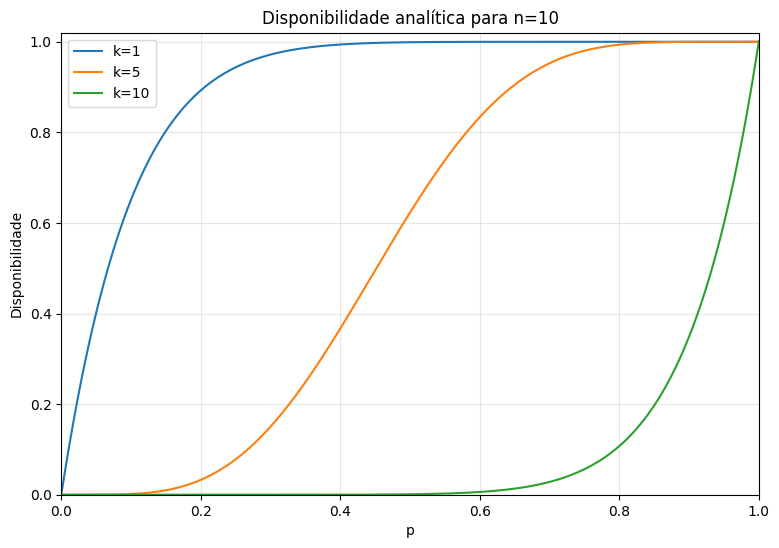

In [6]:
p_grid = np.linspace(0, 1, 201)
n_fixo = 10
k_values = [1, math.ceil(n_fixo / 2), n_fixo]

plt.figure(figsize=(9, 6))

for k in k_values:
    y = [disponibilidade_analitica(n_fixo, k, p) for p in p_grid]
    plt.plot(p_grid, y, label=f"k={k}")

plt.xlabel("p")
plt.ylabel("Disponibilidade")
plt.title(f"Disponibilidade analítica para n={n_fixo}")
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Gráfico 2D — efeito da replicação para \(k=1\)


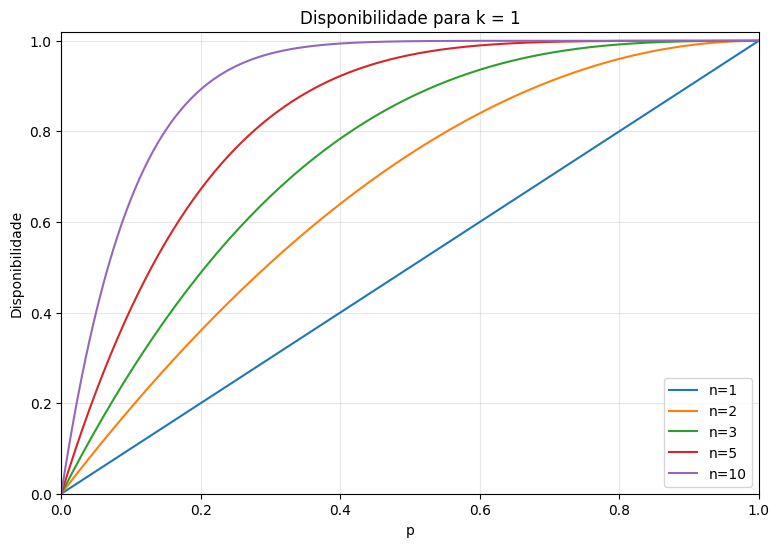

In [7]:
plt.figure(figsize=(9, 6))

for n in [1, 2, 3, 5, 10]:
    y = [disponibilidade_analitica(n, 1, p) for p in p_grid]
    plt.plot(p_grid, y, label=f"n={n}")

plt.xlabel("p")
plt.ylabel("Disponibilidade")
plt.title("Disponibilidade para k = 1")
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Gráfico 2D — efeito da replicação para \(k=n\)


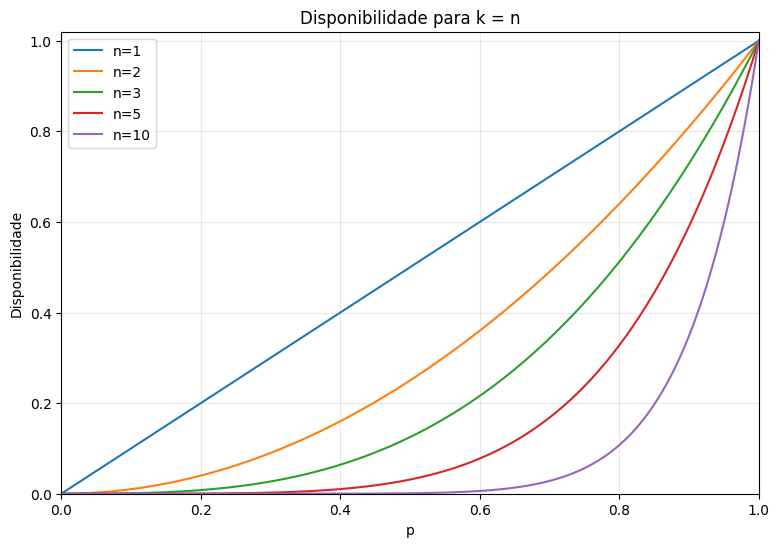

In [8]:
plt.figure(figsize=(9, 6))

for n in [1, 2, 3, 5, 10]:
    y = [disponibilidade_analitica(n, n, p) for p in p_grid]
    plt.plot(p_grid, y, label=f"n={n}")

plt.xlabel("p")
plt.ylabel("Disponibilidade")
plt.title("Disponibilidade para k = n")
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 2. Simulador estocástico

Para cada combinação de \(n\), \(k\) e \(p\), serão realizadas várias rodadas.

Em cada rodada:

1. Um número aleatório entre 0 e 1 é gerado para cada servidor;
2. O servidor é considerado disponível quando o número gerado é menor ou igual a \(p\);
3. Conta-se o número de servidores disponíveis;
4. O serviço é considerado operacional quando pelo menos \(k\) servidores estão disponíveis;
5. A disponibilidade experimental corresponde à proporção de rodadas em que o serviço permaneceu operacional.


In [9]:
def disponibilidade_simulada(n, k, p, rodadas=100_000, rng=None):
    """Estima a disponibilidade por simulação de Monte Carlo."""
    if rng is None:
        rng = np.random.default_rng()

    numeros_aleatorios = rng.random((rodadas, n))
    servidores_disponiveis = numeros_aleatorios <= p
    quantidade_disponiveis = servidores_disponiveis.sum(axis=1)
    servico_operacional = quantidade_disponiveis >= k

    return servico_operacional.mean()


## Comparação entre teoria e prática

Serão utilizadas **100.000 rodadas por combinação**.  
Uma semente fixa é utilizada para tornar os resultados reproduzíveis.


In [10]:
RODADAS = 100_000
rng = np.random.default_rng(42)

resultados_comparacao = []

for n in n_values:
    casos_k = {
        "k = 1": 1,
        "k = ceil(n/2)": math.ceil(n / 2),
        "k = n": n
    }

    for caso, k in casos_k.items():
        for p in p_values:
            analitico = disponibilidade_analitica(n, k, p)
            experimental = disponibilidade_simulada(
                n, k, p,
                rodadas=RODADAS,
                rng=rng
            )

            resultados_comparacao.append({
                "n": n,
                "caso": caso,
                "k": k,
                "p": p,
                "analitico": analitico,
                "experimental": experimental,
                "erro_absoluto": abs(analitico - experimental)
            })

df_comparacao = pd.DataFrame(resultados_comparacao)
df_comparacao


,n,caso,k,p,analitico,experimental,erro_absoluto
0,2,k = 1,1,0.500000,0.750000,0.749720,0.000280
1,2,k = 1,1,0.800000,0.960000,0.959890,0.000110
2,2,k = 1,1,0.900000,0.990000,0.990310,0.000310
3,2,k = 1,1,0.950000,0.997500,0.997480,0.000020
4,2,k = 1,1,0.990000,0.999900,0.999910,0.000010
5,2,k = ceil(n/2),1,0.500000,0.750000,0.749160,0.000840
6,2,k = ceil(n/2),1,0.800000,0.960000,0.960700,0.000700
7,2,k = ceil(n/2),1,0.900000,0.990000,0.989680,0.000320
8,2,k = ceil(n/2),1,0.950000,0.997500,0.997410,0.000090
9,2,k = ceil(n/2),1,0.990000,0.999900,0.999920,0.000020


## Erro entre valor analítico e experimental


In [11]:
df_comparacao["erro_absoluto"].describe()


,erro_absoluto
count,60.000000
mean,0.000449
std,0.000742
min,0.000000
25%,0.000004
50%,0.000091
75%,0.000661
max,0.004070


## Gráficos 2D — valor analítico × valor experimental

Para \(n=10\), serão comparados os casos:

- \(k=1\);
- \(k=5\);
- \(k=10\).

Os pontos experimentais devem ficar muito próximos das curvas analíticas.


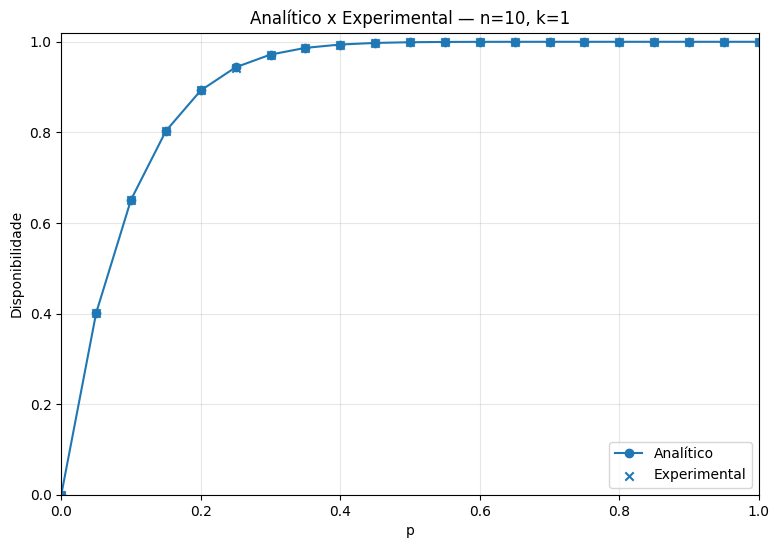

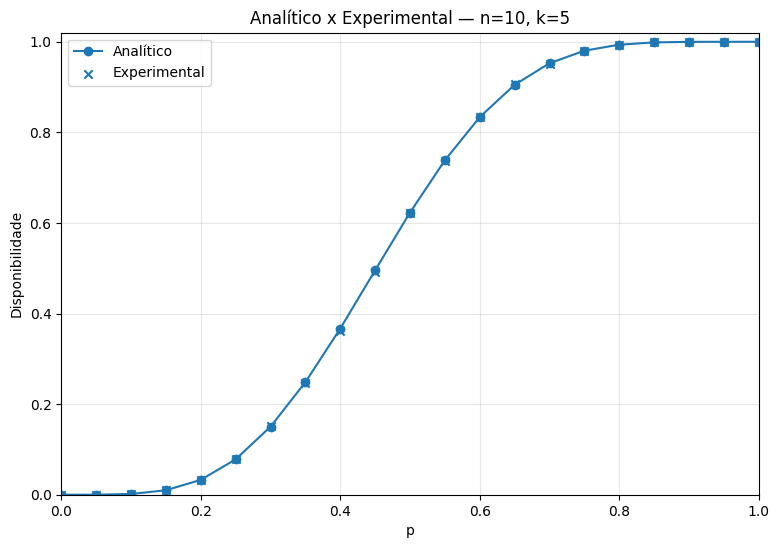

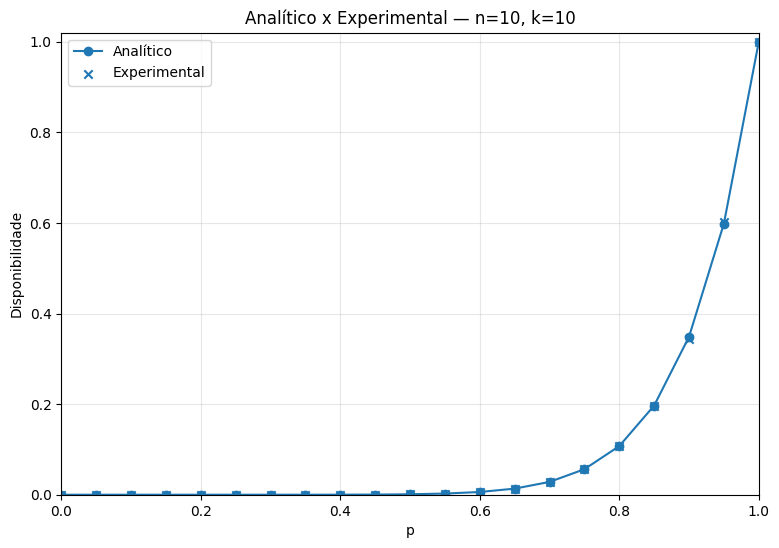

In [12]:
p_sim = np.linspace(0, 1, 21)
n_grafico = 10
k_grafico = [1, math.ceil(n_grafico / 2), n_grafico]

RODADAS_GRAFICO = 50_000
rng_grafico = np.random.default_rng(123)

for k in k_grafico:
    valores_analiticos = [
        disponibilidade_analitica(n_grafico, k, p)
        for p in p_sim
    ]

    valores_experimentais = [
        disponibilidade_simulada(
            n_grafico, k, p,
            rodadas=RODADAS_GRAFICO,
            rng=rng_grafico
        )
        for p in p_sim
    ]

    plt.figure(figsize=(9, 6))
    plt.plot(p_sim, valores_analiticos, marker="o", label="Analítico")
    plt.scatter(p_sim, valores_experimentais, marker="x", label="Experimental")

    plt.xlabel("p")
    plt.ylabel("Disponibilidade")
    plt.title(f"Analítico x Experimental — n={n_grafico}, k={k}")
    plt.xlim(0, 1)
    plt.ylim(0, 1.02)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


## Comparação global

Se a simulação reproduzir corretamente o modelo matemático, os pontos devem ficar próximos da reta \(y=x\).


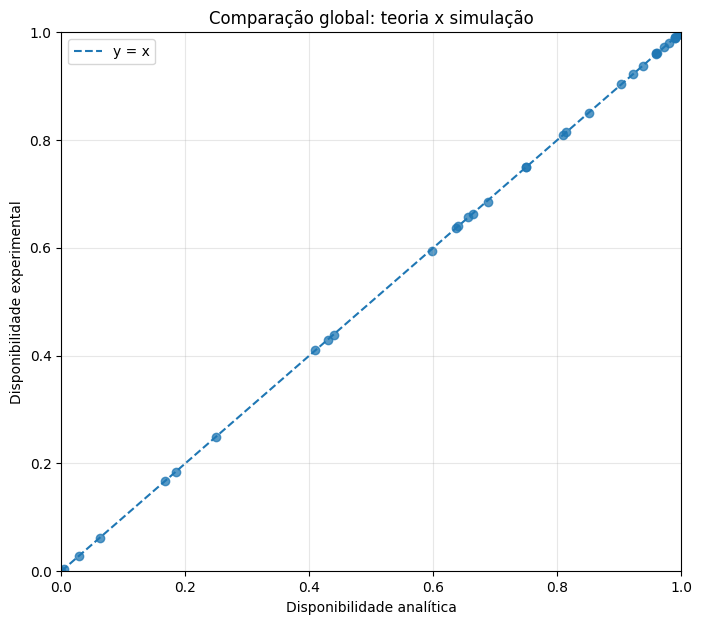

In [13]:
plt.figure(figsize=(8, 7))

plt.scatter(
    df_comparacao["analitico"],
    df_comparacao["experimental"],
    alpha=0.75
)

plt.plot([0, 1], [0, 1], linestyle="--", label="y = x")

plt.xlabel("Disponibilidade analítica")
plt.ylabel("Disponibilidade experimental")
plt.title("Comparação global: teoria x simulação")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Exportação da tabela de resultados

A célula abaixo gera um arquivo CSV com os valores analíticos e experimentais.


In [ ]:
df_comparacao.to_csv("resultados_exercicio_1_2.csv", index=False)
print("Arquivo resultados_exercicio_1_2.csv criado com sucesso.")


# Conclusão

A disponibilidade de um serviço replicado pode ser calculada por:

\[
\boxed{
A(n,k,p)=
\sum_{i=k}^{n}
\binom{n}{i}p^i(1-p)^{n-i}
}
\]

Nos casos extremos:

\[
\boxed{A(n,1,p)=1-(1-p)^n}
\]

\[
\boxed{A(n,n,p)=p^n}
\]

Os resultados mostram que:

- quando \(k=1\), aumentar o número de réplicas aumenta significativamente a disponibilidade;
- quando \(k=n\), exigir todos os servidores simultaneamente reduz a disponibilidade para \(0<p<1\);
- o caso \(k\approx n/2\) possui comportamento intermediário;
- os resultados da simulação estocástica ficam próximos dos valores analíticos;
- pequenas diferenças são esperadas por causa da natureza aleatória da simulação.

Portanto, o simulador valida experimentalmente a fórmula matemática deduzida no Exercício 1.1.
